In [3]:
from deap import tools, creator, base, algorithms, benchmarks
from math import factorial
from numpy import random
from meamt_core import generate_zdt3_front_true, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "zdt3"
NOBJ = 2
K = 10
NDIM = 30
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_zdt3_front_true(10000)

In [ ]:
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)
H = len(ref_points)
MU = H + (4 - H % 4) if H % 4 != 0 else H


In [5]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.zdt3)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [6]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        hv_val = hypervolume(pop, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [7]:
pop, logbook = main()

gen	evals	std                    	min                    	avg                    	max                    	hypervolume	igd_plus
0  	100  	[0.28373726 0.74794425]	[0.00195373 1.8773466 ]	[0.48150647 4.02287678]	[0.97683603 5.71179219]	           	        
1  	100  	[0.26782447 0.87042201]	[9.82664369e-04 1.87734660e+00]	[0.36147922 3.90612607]	[0.92988326 5.67313275]	0          	1.76057 
2  	100  	[0.26509791 0.9089739 ]	[9.82664369e-04 1.67473853e+00]	[0.34076266 3.70011933]	[0.88682385 5.65040405]	0          	1.5791  
3  	100  	[0.2841385  0.99104486]	[9.82664369e-04 1.67473853e+00]	[0.34257443 3.51364758]	[0.88682385 5.65040405]	0          	1.5791  
4  	100  	[0.29106158 0.99631237]	[9.82664369e-04 1.34432127e+00]	[0.36791345 3.27176518]	[0.87175448 5.48367298]	0          	1.29177 
5  	100  	[0.2917966  0.92996788]	[6.43379084e-04 1.34432127e+00]	[0.37235521 3.08293577]	[0.85294537 5.08352311]	0          	1.29177 
6  	100  	[0.28580079 0.90214117]	[6.43379084e-04 1.34432127e+00]	[0.34

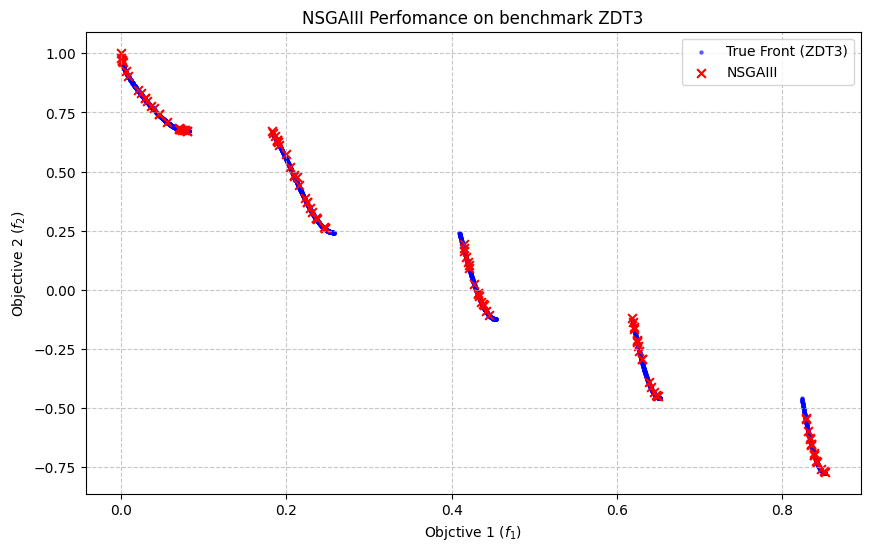

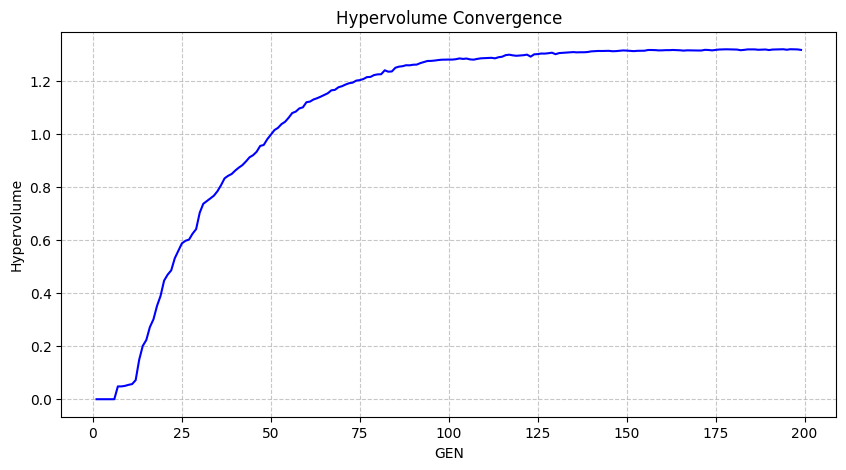

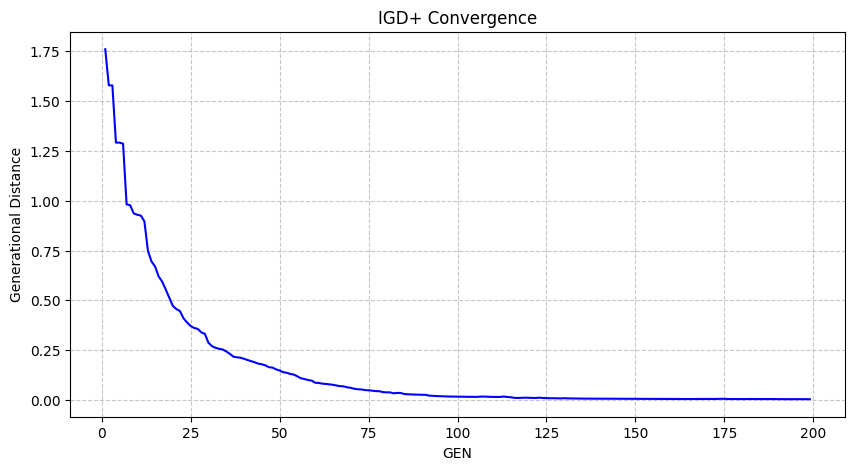

In [8]:
import matplotlib.pyplot as plt

f1_approx = [ind.fitness.values[0] for ind in pop]
f2_approx = [ind.fitness.values[1] for ind in pop]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT3)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='NSGAIII')

plt.title("NSGAIII Perfomance on benchmark ZDT3")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()